In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Dynamics of Two Coupled Nonlinear Auto-Oscillators (STNOs)


\begin{align}\frac{dp_j}{dt}+2p_j\left[\Gamma_{+}(p_j)-\Gamma_{-}(p_j)\right]&=2\sum_k \Omega_{k,j}\sqrt{p_jp_k}\,\cos\!\left(\phi_k-\phi_j+\beta_{k,j}\right)+2F_j\sqrt{p_j}\cos\!\left(\psi_j-\phi_j\right)\\[1em]\frac{d\phi_j}{dt}+\omega_j(p_j)&=\sum_k \Omega_{k,j}\sqrt{\frac{p_k}{p_j}}\,\sin\!\left(\phi_k-\phi_j+\beta_{k,j}\right)+\frac{F_j}{\sqrt{p_j}}\sin\!\left(\psi_j-\phi_j\right)\end{align}

where:
\begin{align}
\omega_j(p) &= \omega_{0j} + Np
\qquad \text{(nonlinear frequency shift)}
\\[0.5em]
\Gamma_{+}(p) &= \Gamma_G(1 + Qp)
\qquad \text{(positive  damping)}
\\[0.5em]
\Gamma_{-}(p) &= \sigma I(1 - p)
\qquad \text{(negative damping)}
\end{align}

In [ ]:
# ─────────────────────────────────────────────
# Parameter Initialisation
# ─────────────────────────────────────────────
class STNOParams:
    def __init__(self):
        self.omega0 = np.array([4.20, 4.22])    # natural frequencies (GHz) — slight dispersion between the two             
        self.N = -0.4                           # coefficient of nonlinear frequency shift           
        self.ΓG = 0.02                          # positive damping rate
        self.Q = 0.5                            # nonlinear damping coefficient
        self.σI = np.array([0.04, 0.04])        # 
        Omega_val = 0.05                        # Coupling matrix Ω_{k,j}    # GHz
        self.Omega = np.array([[0.0,       Omega_val],
                               [Omega_val, 0.0      ]])

        nu = abs(self.N) / (self.ΓG * (self.Q + 1.0))           # Coupling phases β_{k,j}  (rad)
        beta_val = np.arctan(nu)
        self.beta = np.array([[0.0,        beta_val],
                              [beta_val,   0.0     ]])

        # External drives: amplitude F_j (GHz) and phase ψ_j (rad)
        # Set F=0 for free-running (no injection locking)
        self.F   = np.array([0.0, 0.0])        # GHz
        self.psi = np.array([0.0, 0.0])        # rad

    # ── derived quantities ──────────────────
    def omega(self, p):
        return self.omega0 + self.N * p

    def Gamma_plus(self, p):
        return self.ΓG * (1.0 + self.Q * p)

    def Gamma_minus(self, p):
        return self.σI * (1.0 - p)


def stno_rhs(t, state, params):
    """
    state = [p0, p1, phi0, phi1]
    Returns d/dt [p0, p1, phi0, phi1]
    """
    K = 2
    p   = state[:K]                 # powers
    phi = state[K:]                 # phases

    # Guard against negative power (numerical safety)
    p = np.maximum(p, 1e-10)

    Gp  = params.Gamma_plus(p)      # shape (K,)
    Gm  = params.Gamma_minus(p)     # shape (K,)
    w   = params.omega(p)           # shape (K,)

    dp_dt  = np.zeros(K)
    dph_dt = np.zeros(K)

    for j in range(K):
        # ── damping term ──────────────────────
        dp_dt[j]  = -2.0 * p[j] * (Gp[j] - Gm[j])
        dph_dt[j] = -w[j]

        # ── coupling sum over k ───────────────
        for k in range(K):
            if k == j:
                continue
            Okj  = params.Omega[k, j]
            bkj  = params.beta[k, j]
            dphi = phi[k] - phi[j] + bkj

            dp_dt[j]  += 2.0 * Okj * np.sqrt(p[j] * p[k]) * np.cos(dphi)
            dph_dt[j] += Okj * np.sqrt(p[k] / p[j])       * np.sin(dphi)

        # ── external drive ────────────────────
        Fj   = params.F[j]
        psij = params.psi[j]
        dpsi = psij - phi[j]

        dp_dt[j]  += 2.0 * Fj * np.sqrt(p[j]) * np.cos(dpsi)
        dph_dt[j] += (Fj / np.sqrt(p[j]))      * np.sin(dpsi)

    return np.concatenate([dp_dt, dph_dt])

def p_steady(params, j=0):
 
    sI = params.σI[j]
    GG = params.ΓG
    Q  = params.Q
    # (sI - GG) / (sI + GG*Q)  -- from balancing damping terms
    p_star = (sI - GG) / (sI + GG * Q)
    return max(p_star, 0.0)


# ─────────────────────────────────────────────
# Simulation
# ─────────────────────────────────────────────
def run_simulation(params, t_end=500.0, dt=0.01):
    p0_1 = p_steady(params, j=0)
    p0_2 = p_steady(params, j=1)

    # Small perturbation on powers; random initial phases
    rng = np.random.default_rng(42)
    phi0 = rng.uniform(0, 2*np.pi, 2)

    state0 = np.array([p0_1 * 0.9, p0_2 * 1.1, phi0[0], phi0[1]])

    t_eval = np.arange(0, t_end, dt)

    sol = solve_ivp(
        fun=stno_rhs,
        t_span=(0, t_end),
        y0=state0,
        method='RK45',
        t_eval=t_eval,
        args=(params,),
        rtol=1e-8,
        atol=1e-10,
        max_step=0.1
    )

    return sol


In [25]:
params = STNOParams()
sol = run_simulation(params, t_end=500.0, dt=0.01)

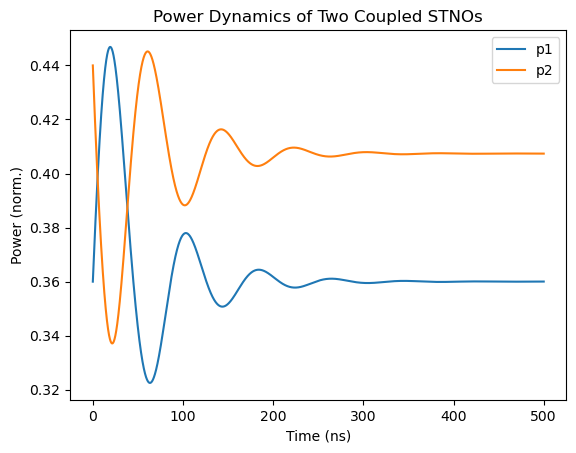

In [26]:


t    = sol.t
p1   = sol.y[0]
p2   = sol.y[1]
phi1 = sol.y[2]
phi2 = sol.y[3]
phi1_uw = np.unwrap(phi1)
phi2_uw = np.unwrap(phi2)
dphi = (phi1_uw - phi2_uw)

plt.plot(t[0:100000], p1[0:100000], label='p1')
plt.plot(t[0:100000], p2[0:100000], label='p2')
plt.xlabel('Time (ns)')
plt.ylabel('Power (norm.)')
plt.title('Power Dynamics of Two Coupled STNOs')
plt.legend()

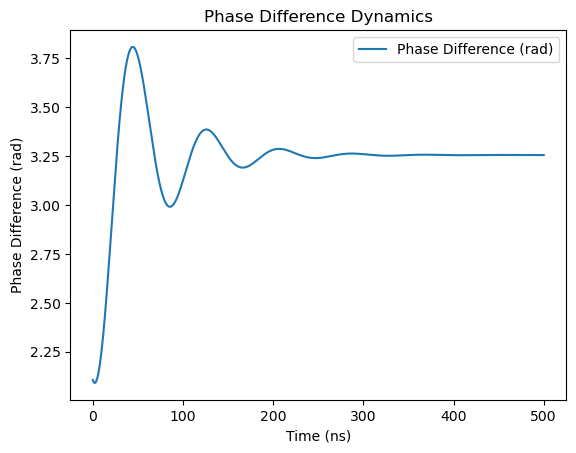

In [27]:
plt.plot(t, dphi, label='Phase Difference (rad)')
plt.xlabel('Time (ns)')
plt.ylabel('Phase Difference (rad)')
plt.title('Phase Difference Dynamics')
plt.legend()
plt.show()

# Memristively Coupled STNO Networks as a Neuromorphic Computing Platform
 
> Training spin-torque nano-oscillator networks to perform computation using memristive synapses and Equilibrium Propagation.
 
---
 
## Overview
 
This project investigates **spin-torque nano-oscillators (STNOs)** coupled through **memristive synapses** as a physical substrate for neuromorphic computing. The central idea is that a network of STNOs, whose coupling strengths are dynamically controlled by memristors, can be trained on machine learning tasks using the **Equilibrium Propagation (eqProp)** algorithm which is a a biologically plausible, hardware-compatible alternative to backpropagation.
 
The key insight driving this work is that the memristor does not act as a static weight but as a **dynamic feedback controller**: its conductance state evolves in response to the voltage signals generated by the oscillators, implementing the eqProp weight update rule in a physically local manner. The STNO's highly nonlinear dynamics governed by the Landau-Lifshitz-Gilbert-Slonczewski (LLGS) equation naturally implement the energy minimization that eqProp requires.


## Instuctions to run
The folder contains one .ipynb file that can be run in Google Colab. I only uses standard libraries available already on Google Colab.

## Repository structure
* The folder named "literature" contains the papers that outline the key ideas that the project is based on.
* The file "report.pdf" contains mathematical derivations of this project.
* "two_oscillators.ipynb" file numerically implements the synchronisation of two Spin Torque Nano Oscillations whose dynamics we derived in report.pdf 


